In [1]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

In [2]:
transform = transforms.ToTensor()

dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

image, label = dataset[0]

print("Image shape:", image.shape)
print("Label:", label)

Image shape: torch.Size([1, 28, 28])
Label: 5


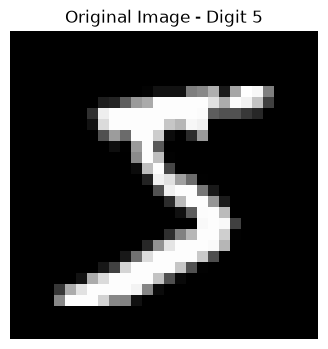

In [3]:
plt.figure(figsize=(4, 4))

plt.imshow(image.squeeze(), cmap="gray")

plt.title(f"Original Image - Digit {label}")
plt.axis("off")

plt.show()

In [4]:
conv = nn.Conv2d(
    in_channels=1,
    out_channels=1,
    kernel_size=3,
    padding=1
)

print(conv)

Conv2d(1, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


In [5]:
image_batch = image.unsqueeze(0)

print(image_batch.shape)

torch.Size([1, 1, 28, 28])


In [6]:
feature_map = conv(image_batch)

print("Input:", image_batch.shape)
print("Output:", feature_map.shape)

Input: torch.Size([1, 1, 28, 28])
Output: torch.Size([1, 1, 28, 28])


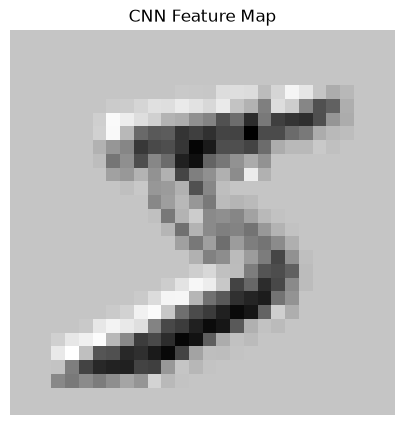

In [7]:
plt.figure(figsize=(5, 5))

plt.imshow(
    feature_map[0, 0].detach(),
    cmap="gray"
)

plt.title("CNN Feature Map")
plt.axis("off")

plt.show()

In [8]:
conv = nn.Conv2d(
    in_channels=1,
    out_channels=8,
    kernel_size=3,
    padding=1
)

feature_maps = conv(image_batch)

print("Feature maps:", feature_maps.shape)

Feature maps: torch.Size([1, 8, 28, 28])


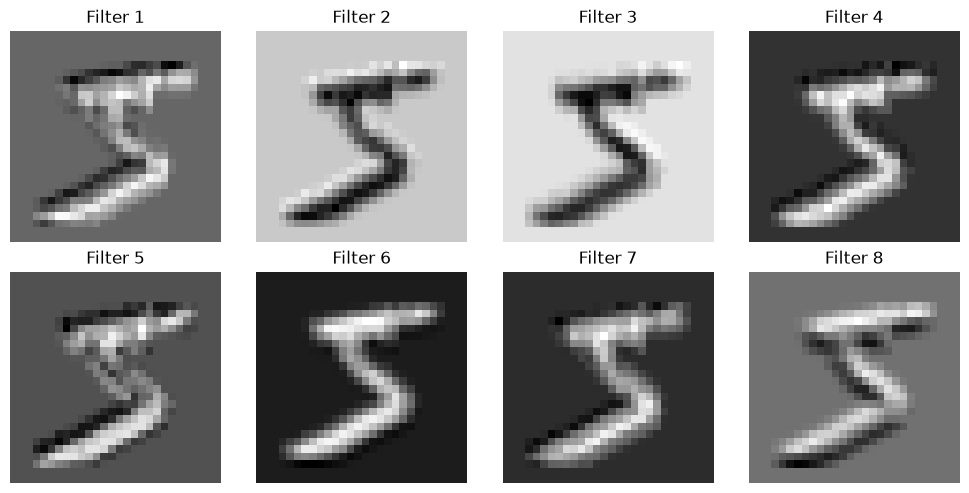

In [9]:
fig, axes = plt.subplots(
    2,
    4,
    figsize=(10, 5)
)

for i, ax in enumerate(axes.flat):

    ax.imshow(
        feature_maps[0, i].detach(),
        cmap="gray"
    )

    ax.set_title(f"Filter {i + 1}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [10]:
pool = nn.MaxPool2d(
    kernel_size=2,
    stride=2
)

In [11]:
pooled = pool(feature_maps)

print("Before pooling:", feature_maps.shape)
print("After pooling:", pooled.shape)

Before pooling: torch.Size([1, 8, 28, 28])
After pooling: torch.Size([1, 8, 14, 14])


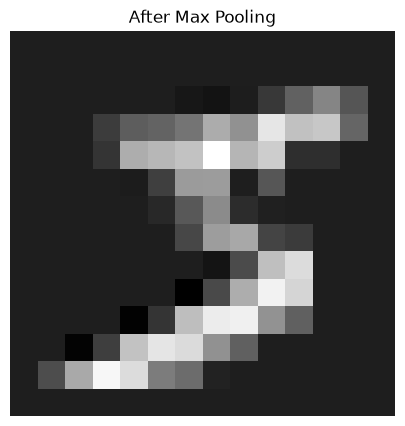

In [12]:
plt.figure(figsize=(5, 5))

plt.imshow(
    pooled[0, 0].detach(),
    cmap="gray"
)

plt.title("After Max Pooling")
plt.axis("off")

plt.show()

In [13]:
class SimpleCNN(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(
            1,
            8,
            kernel_size=3,
            padding=1
        )

        self.relu = nn.ReLU()

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.conv2 = nn.Conv2d(
            8,
            16,
            kernel_size=3,
            padding=1
        )

    def forward(self, x):

        x = self.conv1(x)

        x = self.relu(x)

        x = self.pool(x)

        x = self.conv2(x)

        x = self.relu(x)

        return x

In [14]:
cnn = SimpleCNN()

print(cnn)

SimpleCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)


In [15]:
output = cnn(image_batch)

print("Input shape:", image_batch.shape)
print("Output shape:", output.shape)

Input shape: torch.Size([1, 1, 28, 28])
Output shape: torch.Size([1, 16, 14, 14])


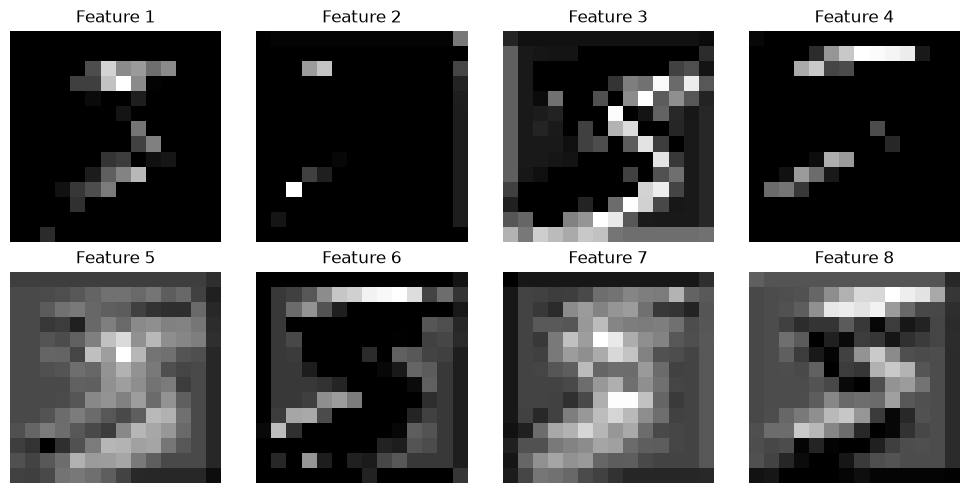

In [16]:
fig, axes = plt.subplots(
    2,
    4,
    figsize=(10, 5)
)

for i, ax in enumerate(axes.flat):

    ax.imshow(
        output[0, i].detach(),
        cmap="gray"
    )

    ax.set_title(f"Feature {i + 1}")
    ax.axis("off")

plt.tight_layout()
plt.show()